In [1]:
print("hello world")

hello world


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
df = pd.read_csv('../Datasets/Iris.csv')
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [4]:
df = df.drop(columns=['Id'])


In [5]:
df['Species'] = df['Species'].map({
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
})

In [6]:
X = df.drop(columns=['Species']).values
y = df['Species'].values

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
def calculate_priors(y_train):
    classes, counts = np.unique(y_train, return_counts=True)
    priors = counts / len(y_train)
    return dict(zip(classes, priors))

In [9]:
priors = calculate_priors(y_train)
print(priors)

{np.int64(0): np.float64(0.3333333333333333), np.int64(1): np.float64(0.3416666666666667), np.int64(2): np.float64(0.325)}


In [10]:
def calculate_statistics(X_train, y_train):
    stats = {}
    
    classes = np.unique(y_train)
    
    for cls in classes:
        X_c = X_train[y_train == cls]
        
        mean = X_c.mean(axis=0)
        var = X_c.var(axis=0)
        
        stats[cls] = {"mean": mean, "var": var}
    
    return stats

In [11]:
stats = calculate_statistics(X_train, y_train)
print(stats[0])

{'mean': array([4.99  , 3.44  , 1.4525, 0.2425]), 'var': array([0.1239    , 0.1549    , 0.03299375, 0.01144375])}


In [12]:
def gaussian_probability(x, mean, var):
    exponent = np.exp(- (x - mean) ** 2 / (2 * var))
    return (1 / np.sqrt(2 * np.pi * var)) * exponent

In [13]:
x = X_train[0]
mean = stats[0]["mean"]
var = stats[0]["var"]

probs = gaussian_probability(x, mean, var)
print(probs)

[0.61348483 0.93324761 0.09865019 3.44629113]


In [16]:
# def predict_single(x, stats, priors):
#     posteriors = {}
    
#     for cls in stats:
#         mean = stats[cls]["mean"]
#         var = stats[cls]["var"]
        
#         likelihoods = gaussian_probability(x, mean, var)
        
#         total_likelihood = np.prod(likelihoods)
        
#         posterior = priors[cls] * total_likelihood
        
#         posteriors[cls] = posterior
    
#     return max(posteriors, key=posteriors.get)

In [17]:
def predict_single(x, stats, priors):
    posteriors = {}
    
    for cls in stats:
        mean = stats[cls]["mean"]
        var = stats[cls]["var"]
        
        # Gaussian likelihood
        likelihoods = gaussian_probability(x, mean, var)
        
        # Convert to log to avoid underflow
        log_likelihood = np.sum(np.log(likelihoods))
        log_prior = np.log(priors[cls])
        
        posterior = log_prior + log_likelihood
        
        posteriors[cls] = posterior
    
    return max(posteriors, key=posteriors.get)

In [18]:
pred = predict_single(X_test[0], stats, priors)
print(pred, y_test[0])

1 1


In [19]:
def predict(X_test, stats, priors):
    predictions = []
    
    for x in X_test:
        label = predict_single(x, stats, priors)
        predictions.append(label)
    
    return np.array(predictions)

In [20]:
y_pred = predict(X_test, stats, priors)
print(y_pred)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [21]:
def accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

acc = accuracy(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 1.0


In [22]:
def confusion_matrix(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    
    for i in range(len(y_true)):
        cm[y_true[i]][y_pred[i]] += 1
    
    return cm

cm = confusion_matrix(y_test, y_pred, num_classes=3)
print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


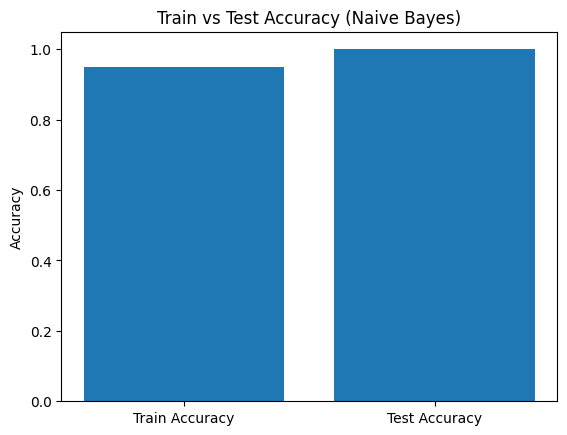

In [23]:
train_preds = predict(X_train, stats, priors)
test_preds = predict(X_test, stats, priors)

train_acc = accuracy(y_train, train_preds)
test_acc = accuracy(y_test, test_preds)

plt.figure()
plt.bar(['Train Accuracy', 'Test Accuracy'], [train_acc, test_acc])

plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy (Naive Bayes)")

plt.show()

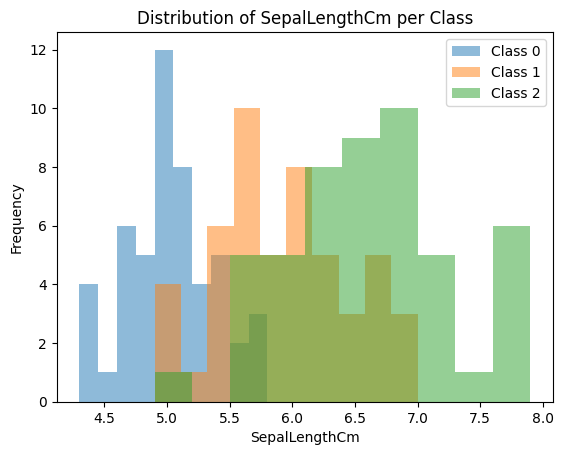

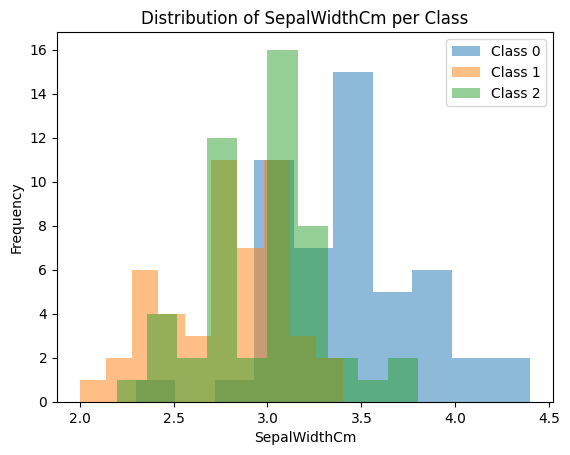

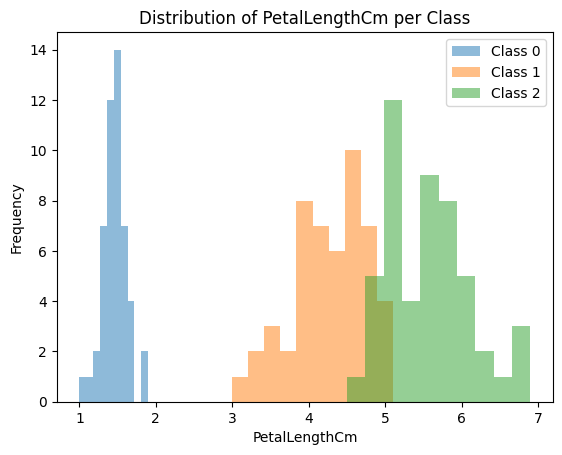

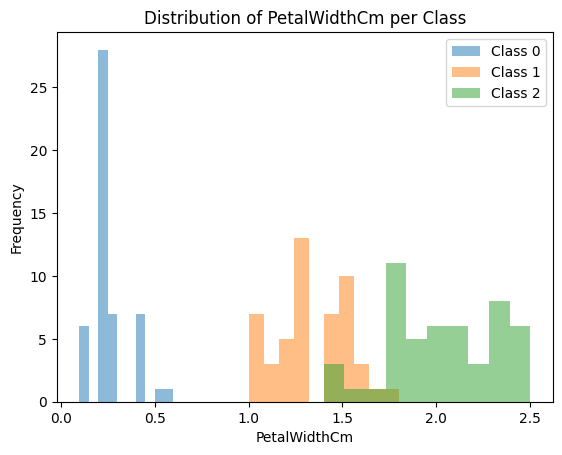

In [24]:
features = df.columns[:-1]

for i, feature in enumerate(features):
    plt.figure()
    
    for cls in np.unique(y):
        plt.hist(X[y == cls, i], bins=10, alpha=0.5, label=f"Class {cls}")
    
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {feature} per Class")
    
    plt.legend()
    plt.show()

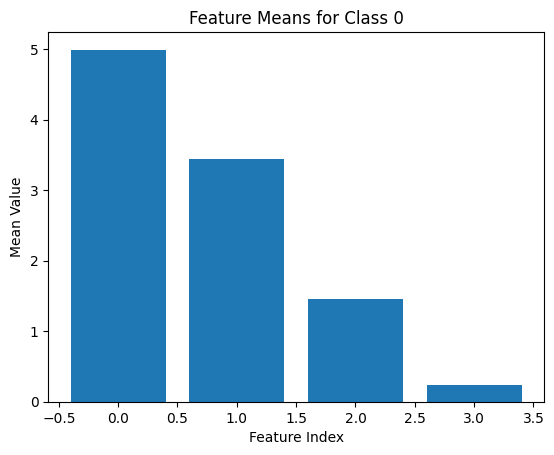

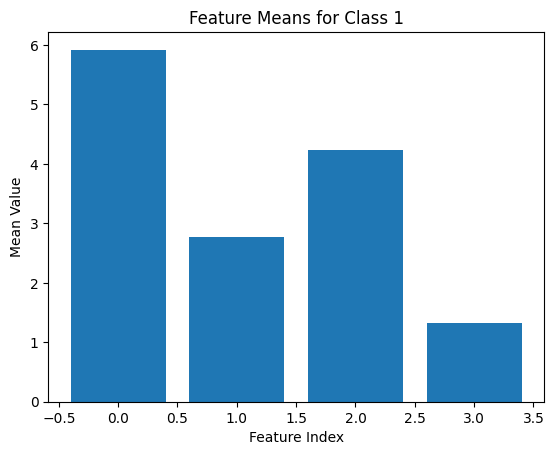

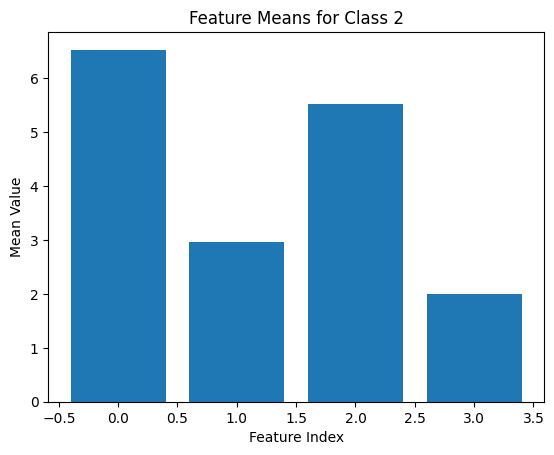

In [25]:
for cls in stats:
    mean = stats[cls]["mean"]
    
    plt.figure()
    plt.bar(range(len(mean)), mean)
    
    plt.title(f"Feature Means for Class {cls}")
    plt.xlabel("Feature Index")
    plt.ylabel("Mean Value")
    
    plt.show()

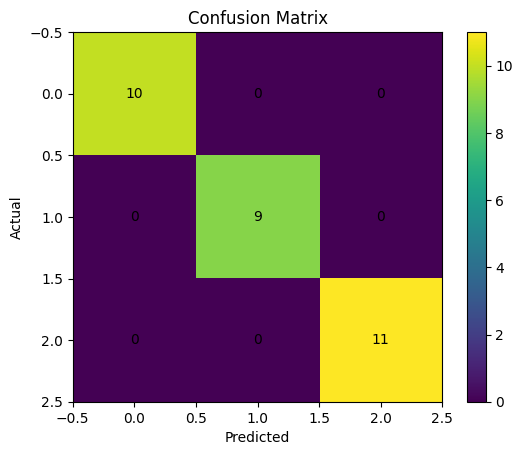

In [26]:
plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()